# Week 11 - Graph Convolution

Graph classification on the MUTAG dataset using a simple graph convolutional network.

## Imports

In [43]:
import torch
from torch.utils.data import random_split
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj, to_dense_batch
import matplotlib.pyplot as plt

## Device

In [44]:
device = 'cpu'

## Load the MUTAG dataset

Split into training, validation, and test sets, and create dataloaders.

In [45]:
dataset = TUDataset(root='../data/', name='MUTAG').to(device)
node_feature_dim = 7

rng = torch.Generator().manual_seed(0)
train_dataset, validation_dataset, test_dataset = random_split(dataset, (100, 44, 44), generator=rng)

train_loader = DataLoader(train_dataset, batch_size=100)
validation_loader = DataLoader(validation_dataset, batch_size=44)
test_loader = DataLoader(test_dataset, batch_size=44)

## Define a simple graph convolution for graph classification

The forward pass currently implements the graph convolution in the **vertex domain**.

**TODO:** Comment out the vertex-domain implementation and re-implement the graph convolution in the **spectral domain**. Verify that the two implementations yield identical results.

In [46]:
class SimpleGraphConv(torch.nn.Module):
    """Simple graph convolution for graph classification.

    forward expects PRE-COMPUTED dense tensors:
        X      : [B, N, F]   dense node features
        A      : [B, N, N]   dense adjacency       (used by domain='vertex')
        Lambda : [B, N]      eigenvalues of A      (used by domain='spectral')
        U      : [B, N, N]   eigenvectors of A     (used by domain='spectral')

    Only the tensors needed by the chosen domain are actually used.
    """

    def __init__(self, node_feature_dim, filter_length, domain='spectral'):
        super().__init__()
        assert domain in ('vertex', 'spectral')
        self.node_feature_dim = node_feature_dim
        self.filter_length = filter_length
        self.domain = domain

        # Graph filter coefficients
        self.h = torch.nn.Parameter(1e-5 * torch.randn(filter_length))
        self.h.data[0] = 1.

        # Output network
        self.output_net = torch.nn.Linear(node_feature_dim, 1)

    def forward(self, X, A=None, Lambda=None, U=None):
        if self.domain == 'vertex':
            # y = sum_k h[k] * A^k * X
            assert A is not None, "vertex domain needs A"
            node_state = torch.zeros_like(X)
            for k in range(self.filter_length):
                node_state = node_state + self.h[k] * torch.linalg.matrix_power(A, k) @ X
        else:
            # y = U * diag( sum_k h[k] * Lambda^k ) * U^T * X
            assert Lambda is not None and U is not None, "spectral domain needs Lambda and U"
            powers = torch.stack([Lambda**k for k in range(self.filter_length)], dim=-1)
            H = powers @ self.h
            node_state = U @ (H.unsqueeze(-1) * (U.transpose(-1, -2) @ X))

        graph_state = node_state.sum(1)
        return self.output_net(graph_state).flatten()

## Precompute dense tensors and eigendecompositions

The eigendecomposition of the adjacency is the bottleneck of the spectral form, but it does not depend on the model parameters - it only depends on the graph. We compute it **once per batch up front**, together with the dense feature/adjacency tensors, and reuse them across every epoch.

This also lets us verify, on the first batch, that the spectral implementation matches a vertex-domain reference.

In [47]:
def precompute_batches(loader):
    """Run to_dense_batch / to_dense_adj / eigh once per batch and cache the result."""
    cached = []
    for data in loader:
        A = to_dense_adj(data.edge_index, data.batch)            # [B, N, N]
        X, _ = to_dense_batch(data.x, data.batch)                # [B, N, F]
        Lambda, U = torch.linalg.eigh(A)                         # [B, N], [B, N, N]
        cached.append({
            'X': X, 'A': A, 'Lambda': Lambda, 'U': U,
            'y': data.y.float(),
            'batch_size': data.batch_size,
        })
    return cached

train_batches      = precompute_batches(train_loader)
validation_batches = precompute_batches(validation_loader)
test_batches       = precompute_batches(test_loader)

# Sanity check: spectral form should match vertex form (same parameters)
torch.manual_seed(0)
_m_v = SimpleGraphConv(node_feature_dim, filter_length=3, domain='vertex').to(device)
_m_s = SimpleGraphConv(node_feature_dim, filter_length=3, domain='spectral').to(device)
_m_s.load_state_dict(_m_v.state_dict())

b = train_batches[0]
with torch.no_grad():
    y_v = _m_v(b['X'], A=b['A'])
    y_s = _m_s(b['X'], Lambda=b['Lambda'], U=b['U'])
print(f"max |vertex - spectral| = {(y_v - y_s).abs().max().item():.2e}")
assert torch.allclose(y_v, y_s, atol=1e-4)
print('OK - spectral matches vertex domain.')

max |vertex - spectral| = 6.56e-07
OK - spectral matches vertex domain.


## Set up the model, loss, and optimizer

In [48]:
filter_length = 3
domain = 'spectral'   # 'spectral' or 'vertex'

torch.manual_seed(1)
model = SimpleGraphConv(node_feature_dim, filter_length, domain=domain).to(device)

cross_entropy = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1.)

scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.995)

## Lists to store accuracy and loss

In [49]:
train_accuracies = []
train_losses = []
validation_accuracies = []
validation_losses = []

## Fit the model

In [50]:
epochs = 500

def model_forward(b):
    if model.domain == 'vertex':
        return model(b['X'], A=b['A'])
    return model(b['X'], Lambda=b['Lambda'], U=b['U'])

for epoch in range(epochs):
    # Train
    model.train()
    train_accuracy = 0.
    train_loss = 0.
    for b in train_batches:
        out = model_forward(b)
        loss = cross_entropy(out, b['y'])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_accuracy += sum((out > 0) == b['y'].bool()).detach().cpu() / len(train_loader.dataset)
        train_loss += loss.detach().cpu().item() * b['batch_size'] / len(train_loader.dataset)

    scheduler.step()

    # Validate
    with torch.no_grad():
        model.eval()
        validation_loss = 0.
        validation_accuracy = 0.
        for b in validation_batches:
            out = model_forward(b)
            validation_accuracy += sum((out > 0) == b['y'].bool()).cpu() / len(validation_loader.dataset)
            validation_loss += cross_entropy(out, b['y']).cpu().item() * b['batch_size'] / len(validation_loader.dataset)

        train_accuracies.append(train_accuracy)
        train_losses.append(train_loss)
        validation_losses.append(validation_loss)
        validation_accuracies.append(validation_accuracy)

        if (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'- Learning rate   = {scheduler.get_last_lr()[0]:.1e}')
            print(f'- Train. accuracy = {train_accuracy:.3f}')
            print(f'         loss     = {train_loss:.3f}')
            print(f'- Valid. accuracy = {validation_accuracy:.3f}')
            print(f'         loss     = {validation_loss:.3f}')

Epoch 50
- Learning rate   = 7.8e-01
- Train. accuracy = 0.790
         loss     = 1.376
- Valid. accuracy = 0.705
         loss     = 1.642
Epoch 100
- Learning rate   = 6.1e-01
- Train. accuracy = 0.860
         loss     = 0.333
- Valid. accuracy = 0.727
         loss     = 0.452
Epoch 150
- Learning rate   = 4.7e-01
- Train. accuracy = 0.890
         loss     = 0.295
- Valid. accuracy = 0.795
         loss     = 0.379
Epoch 200
- Learning rate   = 3.7e-01
- Train. accuracy = 0.890
         loss     = 0.286
- Valid. accuracy = 0.795
         loss     = 0.362
Epoch 250
- Learning rate   = 2.9e-01
- Train. accuracy = 0.890
         loss     = 0.281
- Valid. accuracy = 0.841
         loss     = 0.354
Epoch 300
- Learning rate   = 2.2e-01
- Train. accuracy = 0.890
         loss     = 0.279
- Valid. accuracy = 0.841
         loss     = 0.350
Epoch 350
- Learning rate   = 1.7e-01
- Train. accuracy = 0.890
         loss     = 0.277
- Valid. accuracy = 0.841
         loss     = 0.348
Epoch 4

## Plot training curves

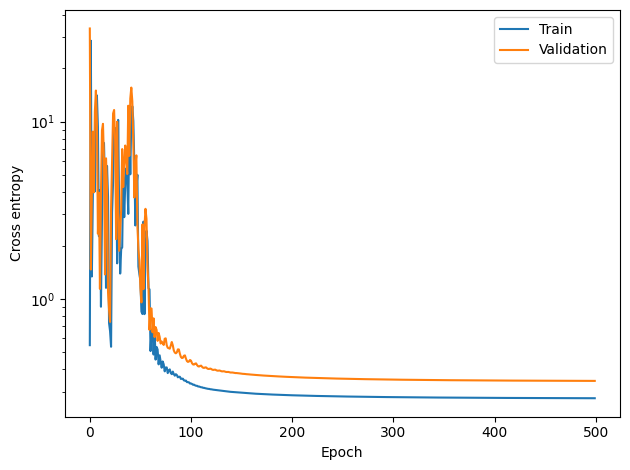

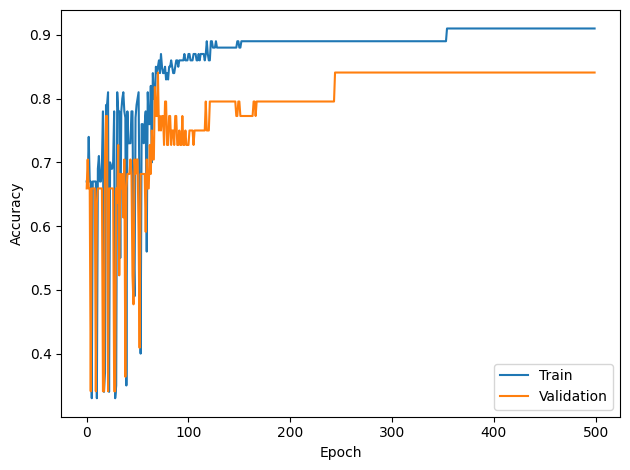

In [51]:
plt.figure('Loss')
plt.plot(train_losses, label='Train')
plt.plot(validation_losses, label='Validation')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Cross entropy')
plt.yscale('log')
plt.tight_layout()
plt.show()

plt.figure('Accuracy')
plt.plot(train_accuracies, label='Train')
plt.plot(validation_accuracies, label='Validation')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

## Save final predictions

In [ ]:
with torch.no_grad():
    model.eval()
    b = test_batches[0]
    if model.domain == 'vertex':
        out = model(b['X'], A=b['A']).cpu()
    else:
        out = model(b['X'], Lambda=b['Lambda'], U=b['U']).cpu()
    torch.save(out, 'test_predictions.pt')